# Compute the potential density from WOA18 T and S

In [1]:
%matplotlib inline

import numpy as np
import xesmf as xe
import xarray as xr
import netCDF4 as nc
import cmocean as cm
import matplotlib.ticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
import matplotlib.gridspec as gridspec
from gsw import sigma0, sigma1, sigma2
from scipy.io import savemat

import warnings
warnings.filterwarnings('ignore')

## Load the WOA18 climatological T and S

In [2]:
woa18_t00 = xr.open_dataset('/g/data/nm03/lxy581/WOA18/woa18_decav_t00_04.nc',drop_variables='time')
woa18_s00 = xr.open_dataset('/g/data/nm03/lxy581/WOA18/woa18_decav_s00_04.nc',drop_variables='time')

lon = woa18_t00.lon
lat = woa18_t00.lat
dep = woa18_t00.depth

t_an = woa18_t00.t_an.squeeze()
s_an = woa18_s00.s_an.squeeze()

nx = lon.size
ny = lat.size
nz = dep.size

## Compute the 3D potential density

In [3]:
sigma0_3D = sigma0(s_an,t_an)
sigma1_3D = sigma1(s_an,t_an)
sigma2_3D = sigma2(s_an,t_an)

In [4]:
print(sigma0_3D.shape)
print(sigma1_3D.shape)
print(sigma2_3D.shape)

print(dep.shape)

(102, 720, 1440)
(102, 720, 1440)
(102, 720, 1440)
(102,)


In [5]:
N3D_data = xr.Dataset({'sigma0': (('depth','lat','lon'), np.array(sigma0_3D)),
                       'sigma1': (('depth','lat','lon'), np.array(sigma1_3D)),
                       'sigma2': (('depth','lat','lon'), np.array(sigma2_3D))}, 
                       coords={'depth':np.array(woa18_t00.depth),
                               'lon':np.array(woa18_t00.lon),
                               'lat':np.array(woa18_t00.lat)})

N3D_data.to_netcdf('/g/data/nm03/lxy581/WOA18/sigma_3D_woa18.nc')

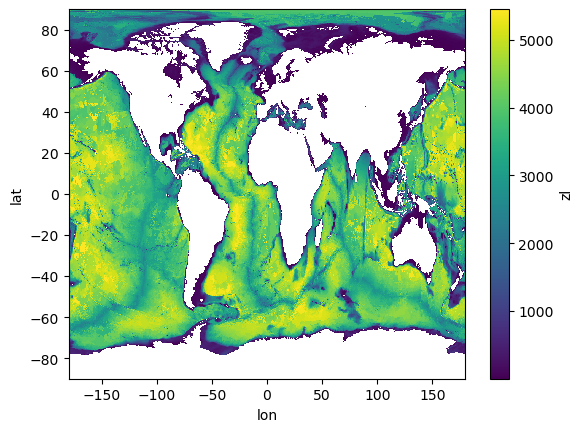

In [6]:
N_data = xr.open_dataset('/g/data/nm03/lxy581/WOA18/N3D_prof_woa18.nc')
N_data = N_data.rename({'depth': 'zl'})
valid = N_data.N.notnull()
max_depth = N_data.zl.where(valid).max("zl")
max_depth.plot()

In [7]:
mask = (abs(woa18_t00.lat) < 74.4) & (max_depth > 1000)
sigma0_profile = sigma0_3D.where(mask).mean(("lat", "lon"), skipna=True)
sigma0_profile

<xarray.DataArray 's_an' (depth: 102)> Size: 816B
array([24.77160468, 24.78849704, 24.80885228, 24.82757429, 24.85104573,
       24.88216402, 24.91924139, 24.96387161, 25.01358686, 25.06739408,
       25.12255841, 25.18002563, 25.23806018, 25.29644332, 25.35428999,
       25.41130017, 25.46760494, 25.52335911, 25.57760494, 25.63102292,
       25.68240851, 25.9142    , 26.10331108, 26.25393199, 26.37289909,
       26.46668811, 26.5436463 , 26.6076782 , 26.66326878, 26.7125392 ,
       26.75660193, 26.79671721, 26.83340054, 26.86697253, 26.8978564 ,
       26.92644604, 26.95346211, 27.0020178 , 27.04516677, 27.08461607,
       27.12209334, 27.15733007, 27.19102016, 27.2234169 , 27.25544339,
       27.28485738, 27.31246952, 27.33842749, 27.36259121, 27.38512952,
       27.40609161, 27.42566323, 27.44389286, 27.46076643, 27.47651611,
       27.49095319, 27.50440026, 27.51738611, 27.5288268 , 27.53949402,
       27.54929025, 27.55841231, 27.56681296, 27.57468717, 27.58179532,
       27.58832321, 27.59558356, 27.60874503, 27.62145797, 27.6293132 ,
       27.63558103, 27.64054854, 27.64472267, 27.64832669, 27.65151569,
       27.65391518, 27.65639681, 27.6586785 , 27.66080647, 27.66275345,
       27.66467168, 27.66652985, 27.6681278 , 27.66952436, 27.67086951,
       27.67212096, 27.67351768, 27.67436862, 27.67487762, 27.67512152,
       27.67517295, 27.67493125, 27.67441018, 27.67376059, 27.67281131,
       27.67153394, 27.66999681, 27.66782105, 27.6648297 , 27.66159181,
       27.65785056, 27.65456685])
Coordinates:
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03

In [8]:
sigma1_profile = sigma1_3D.where(mask).mean(("lat", "lon"), skipna=True)
sigma1_profile

<xarray.DataArray 's_an' (depth: 102)> Size: 816B
array([29.13639164, 29.15398896, 29.17512212, 29.19459968, 29.21903059,
       29.25151967, 29.29030362, 29.33707402, 29.38924774, 29.44576116,
       29.50372593, 29.56419218, 29.6252664 , 29.68672498, 29.74762898,
       29.80766293, 29.86693648, 29.92561023, 29.98269391, 30.03889356,
       30.09297413, 30.33698154, 30.53699606, 30.69781578, 30.8264194 ,
       30.92903239, 31.01426223, 31.08597475, 31.1489152 , 31.20524643,
       31.25609794, 31.30276426, 31.34578826, 31.38541044, 31.42209328,
       31.45624675, 31.48864717, 31.54713914, 31.5992098 , 31.64678407,
       31.69174081, 31.73384862, 31.7738712 , 31.81216921, 31.84988478,
       31.88438794, 31.91663862, 31.9467905 , 31.97477484, 32.00077913,
       32.02490702, 32.04741106, 32.06842457, 32.08791585, 32.10610114,
       32.12282736, 32.13845183, 32.15364603, 32.16701372, 32.17950499,
       32.19101707, 32.20174602, 32.21167546, 32.22100375, 32.22948595,
       32.23729828, 32.2459586 , 32.26158305, 32.27640398, 32.2861447 ,
       32.29411267, 32.30066612, 32.3063223 , 32.31131598, 32.3158384 ,
       32.31953849, 32.32318786, 32.32658617, 32.32978653, 32.33280365,
       32.33578946, 32.33870805, 32.34129309, 32.343658  , 32.34592389,
       32.34805313, 32.35029376, 32.35185899, 32.35290926, 32.35349387,
       32.35373369, 32.35348509, 32.35285525, 32.35197827, 32.35069901,
       32.34913663, 32.34701001, 32.34407401, 32.33979836, 32.33498506,
       32.32970176, 32.32541236])
Coordinates:
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03

In [9]:
sigma2_profile = sigma2_3D.where(mask).mean(("lat", "lon"), skipna=True)
sigma2_profile

<xarray.DataArray 's_an' (depth: 102)> Size: 816B
array([33.40513185, 33.42341444, 33.4453041 , 33.46551626, 33.49087998,
       33.52470163, 33.56514446, 33.61399504, 33.66855821, 33.72770176,
       33.7883881 , 33.85176885, 33.91579692, 33.98024405, 34.04411893,
       34.10709106, 34.16924925, 34.23075973, 34.29060068, 34.34950294,
       34.40620181, 34.66207632, 34.87268196, 35.04340787, 35.18137158,
       35.29255543, 35.38581979, 35.4649928 , 35.53507252, 35.59826227,
       35.65570808, 35.70873778, 35.75792087, 35.80342   , 35.84573585,
       35.88529394, 35.92292474, 35.99106901, 36.05180663, 36.10727411,
       36.1594972 , 36.20828052, 36.25445548, 36.2984871 , 36.34173031,
       36.38117834, 36.41793619, 36.45216333, 36.48386029, 36.51323266,
       36.540437  , 36.56579074, 36.58950964, 36.61154485, 36.63209714,
       36.65104803, 36.66878865, 36.68612904, 36.70136955, 36.7156336 ,
       36.72881332, 36.74110403, 36.75251937, 36.76326093, 36.77307862,
       36.78213938, 36.79216046, 36.81017879, 36.82704856, 36.83862193,
       36.84824241, 36.85633736, 36.86343403, 36.86977841, 36.87559684,
       36.88056098, 36.88534535, 36.88982898, 36.8940717 , 36.89812899,
       36.90215251, 36.90610184, 36.90964636, 36.91295254, 36.91611344,
       36.91909593, 36.92215691, 36.9244165 , 36.92599292, 36.92690872,
       36.92733167, 36.92707635, 36.92634075, 36.92524269, 36.92364261,
       36.92180311, 36.91910333, 36.9154282 , 36.90990395, 36.90355903,
       36.89677649, 36.89150932])
Coordinates:
  * depth    (depth) float32 408B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03